# 🫀 Cardiac Patient Monitoring System — Full Project Notebook


## 📖 Introduction

This is the complete individual AI & Machine Learning capstone project: an end-to-end analysis of
cardiovascular disease risk using the **Cardiovascular Disease dataset** (`cardio_train.csv`,
70,000 patient records). Per my mentor's guidance, this notebook covers every topic through the
end of Week 4 of the training track — data preparation, EDA, supervised classification (a
baseline and a comparison model), cross-validation and evaluation, and feature engineering with a
Scikit-learn Pipeline. It does not include the unsupervised (clustering/PCA) section, which is a
later-track topic not yet covered.

This single notebook is organized into clearly numbered sections so it can be read and run
top to bottom without needing any other file.


## 🎯 Project Objectives

By the end of this notebook, I will have:
- Loaded and cleaned a real-world healthcare dataset, documenting the target and any data-quality issues.
- Explored the data with descriptive statistics, visualizations, and a correlation analysis.
- Trained and evaluated a baseline classifier and a comparison classifier under the same split.
- Evaluated both models with cross-validation, a confusion matrix, and standard classification metrics.
- Engineered new features and packaged preprocessing + modeling into a single, reusable Scikit-learn Pipeline.


## 🛠 Libraries Used


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 4)


---
# 1️⃣ Environment & Dataset


## 📋 Data Dictionary

| Column | Description | Type |
|---|---|---|
| `id` | Row identifier | int |
| `age` | Age in days | int |
| `gender` | 1 = women, 2 = men | categorical |
| `height` | Height (cm) | int |
| `weight` | Weight (kg) | float |
| `ap_hi` | Systolic blood pressure | int |
| `ap_lo` | Diastolic blood pressure | int |
| `cholesterol` | 1 = normal, 2 = above normal, 3 = well above normal | ordinal |
| `gluc` | 1 = normal, 2 = above normal, 3 = well above normal | ordinal |
| `smoke` | Whether the patient smokes | binary |
| `alco` | Whether the patient drinks alcohol | binary |
| `active` | Whether the patient is physically active | binary |
| `cardio` | **Target** — presence (1) or absence (0) of cardiovascular disease | binary |

`age` is stored in days rather than years, converted to years during cleaning below.


In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")
print(df.shape)
df.head()


(70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


### 📌 Interpretation

70,000 rows, 13 columns, every column numeric, no missing values. That doesn't guarantee the
*values* themselves are valid — checked next.


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Target distribution:")
print(df["cardio"].value_counts(normalize=True).round(4))


Duplicate rows: 0

Target distribution:
cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


### 📌 Interpretation

No duplicates, and the target is close to perfectly balanced (~50/50) — a favorable property that
means no class-imbalance correction is needed for a fair baseline later.


---
# 2️⃣ Data Preparation


## 🩺 Checking for Data-Quality Issues

Real health measurements have physical limits. A systolic blood pressure of thousands of mmHg
isn't a missing value — it's an impossible one.


In [5]:
df[["age", "height", "weight", "ap_hi", "ap_lo"]].describe()


,age,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,164.359229,74.205690,128.817286,96.630414
std,2467.251667,8.210126,14.395757,154.011419,188.472530
min,10798.000000,55.000000,10.000000,-150.000000,-70.000000
25%,17664.000000,159.000000,65.000000,120.000000,80.000000
50%,19703.000000,165.000000,72.000000,120.000000,80.000000
75%,21327.000000,170.000000,82.000000,140.000000,90.000000
max,23713.000000,250.000000,200.000000,16020.000000,11000.000000


### 📌 Interpretation

`ap_hi` ranges from -150 to 16020 and `ap_lo` from -70 to 11000 — both far outside any plausible
blood pressure reading (normal adult range is roughly 90–200 mmHg systolic). `height` (55–250 cm)
and `weight` (10–200 kg) also contain physically implausible extremes for this adult population.
These are documented data-entry outliers in this specific dataset, not signs the data is unusable
— they need filtering before modeling, done below.


In [6]:
data = df.copy()

# Convert age from days to years
data["age_years"] = (data["age"] / 365.25).round(1)
data = data.drop(columns=["id", "age"])

# Filter out physically implausible readings
before = len(data)
data = data[
    (data["ap_hi"] >= 60) & (data["ap_hi"] <= 250) &
    (data["ap_lo"] >= 40) & (data["ap_lo"] <= 200) &
    (data["ap_hi"] > data["ap_lo"]) &
    (data["height"] >= 120) & (data["height"] <= 220) &
    (data["weight"] >= 30) & (data["weight"] <= 200)
]
after = len(data)

print(f"Rows before filtering: {before}")
print(f"Rows after filtering:  {after}")
print(f"Rows removed: {before - after} ({(before - after) / before:.2%})")


Rows before filtering: 70000
Rows after filtering:  68616
Rows removed: 1384 (1.98%)


### 📌 Interpretation

Filtering removes a small fraction of rows (about 2%) — the implausible readings are a minority,
so the dataset's size and statistical power are barely affected, while every remaining row now
has believable clinical values.


In [7]:
data.isnull().sum().sum()


np.int64(0)

---
# 3️⃣ EDA & Statistics


## 🔢 Descriptive Statistics


In [8]:
data.describe().round(2)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,68616.00,68616.00,68616.00,68616.00,68616.00,68616.00,68616.00,68616.00,68616.00,68616.0,68616.00,68616.00
mean,1.35,164.41,74.11,126.68,81.31,1.36,1.23,0.09,0.05,0.8,0.49,53.29
std,0.48,7.91,14.30,16.69,9.45,0.68,0.57,0.28,0.22,0.4,0.50,6.76
min,1.00,120.00,30.00,60.00,40.00,1.00,1.00,0.00,0.00,0.0,0.00,29.60
25%,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00,48.30
50%,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00,53.90
75%,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.00,58.40
max,2.00,207.00,200.00,240.00,182.00,3.00,3.00,1.00,1.00,1.0,1.00,64.90


### 📌 Interpretation

Average patient age is about 53 years. Average systolic BP (`ap_hi`) is ~127 mmHg and diastolic
(`ap_lo`) ~81 mmHg — both plausible after filtering.


## 📈 Distributions


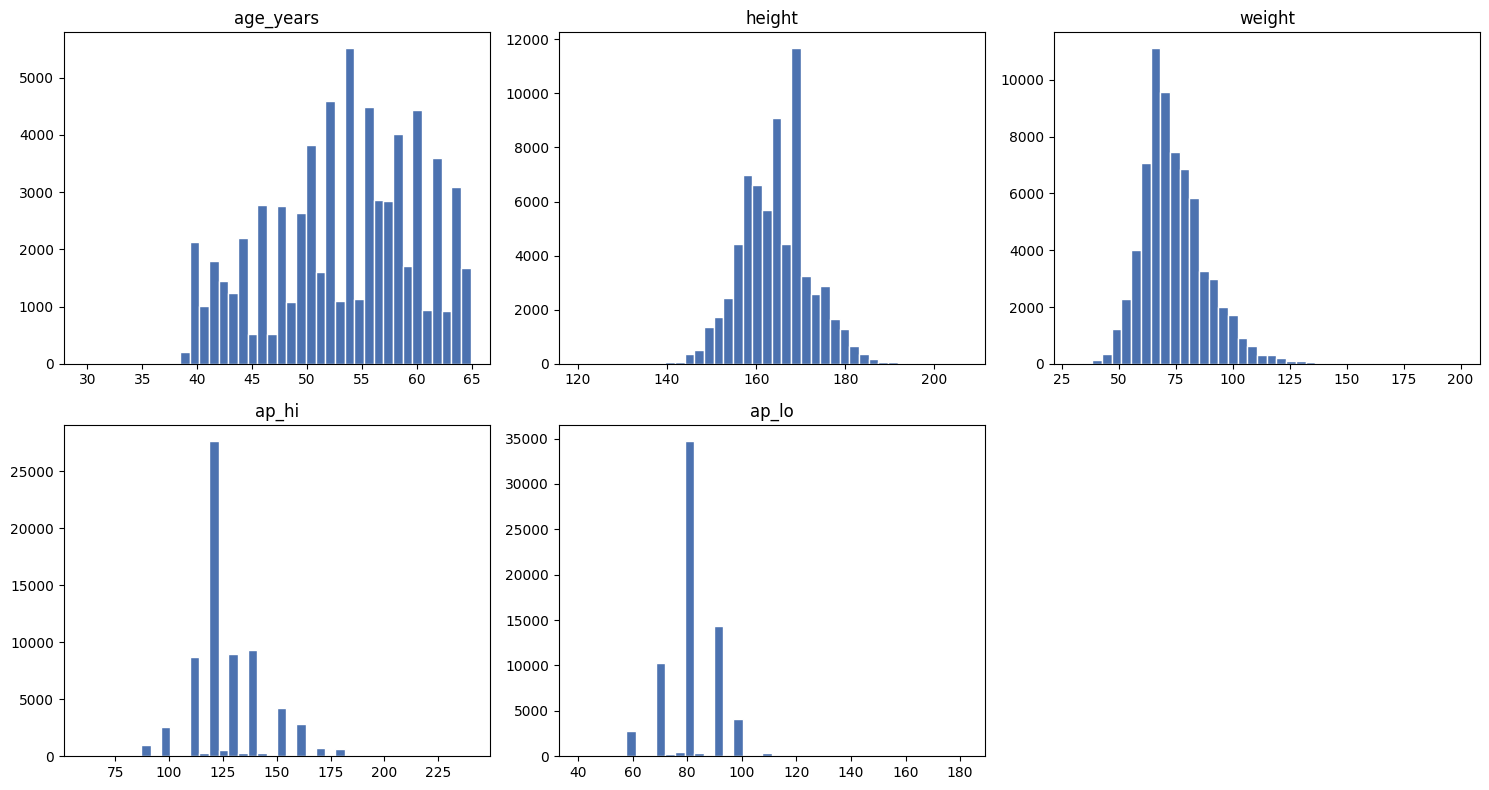

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
numeric_cols = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(data[col], bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(col)

axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


### 📌 Interpretation

`age_years` spans roughly 30–65 with a concentration in the 50s. `height`/`weight` are
roughly bell-shaped around plausible adult values. `ap_hi`/`ap_lo` cluster around common clinical
readings (e.g. 120/80, 140/90), showing as spikes rather than a smooth curve — a natural result of
blood pressure often being recorded in round numbers.


## 🔗 Feature–Target Relationships


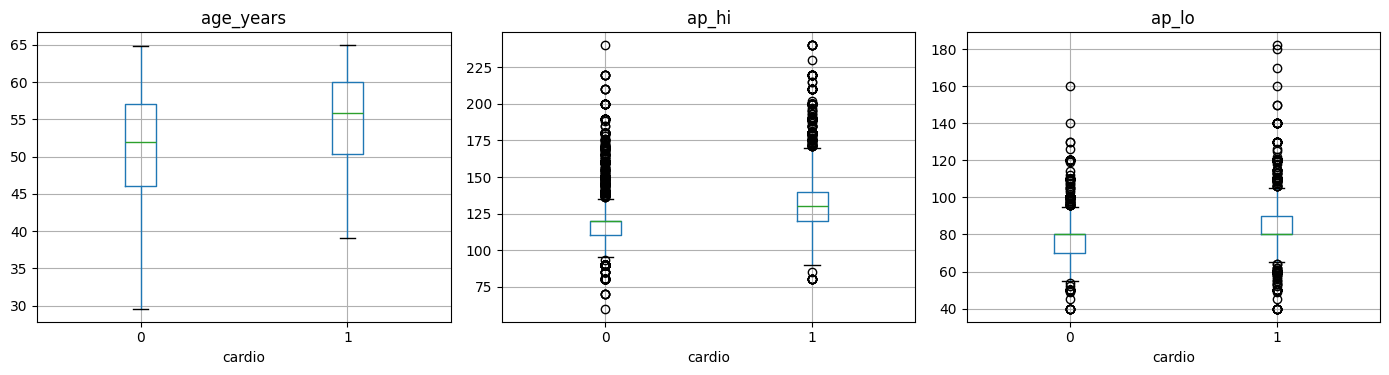

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["age_years", "ap_hi", "ap_lo"]):
    data.boxplot(column=col, by="cardio", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("cardio")

plt.suptitle("")
plt.tight_layout()
plt.show()


In [11]:
chol_cardio = pd.crosstab(data["cholesterol"], data["cardio"], normalize="index").round(3)
chol_cardio.columns = ["No Cardio", "Cardio"]
chol_cardio


,No Cardio,Cardio
cholesterol,,
1,0.565,0.435
2,0.404,0.596
3,0.238,0.762


### 📌 Interpretation

Patients with cardiovascular disease skew visibly older and have higher blood pressure. The
cardiovascular disease rate also rises sharply with cholesterol level — from about 44% at normal
cholesterol to roughly 76% at "well above normal." This is real, non-trivial predictive signal
spread across several features rather than one dominant shortcut feature.


## 🌡 Correlation Analysis


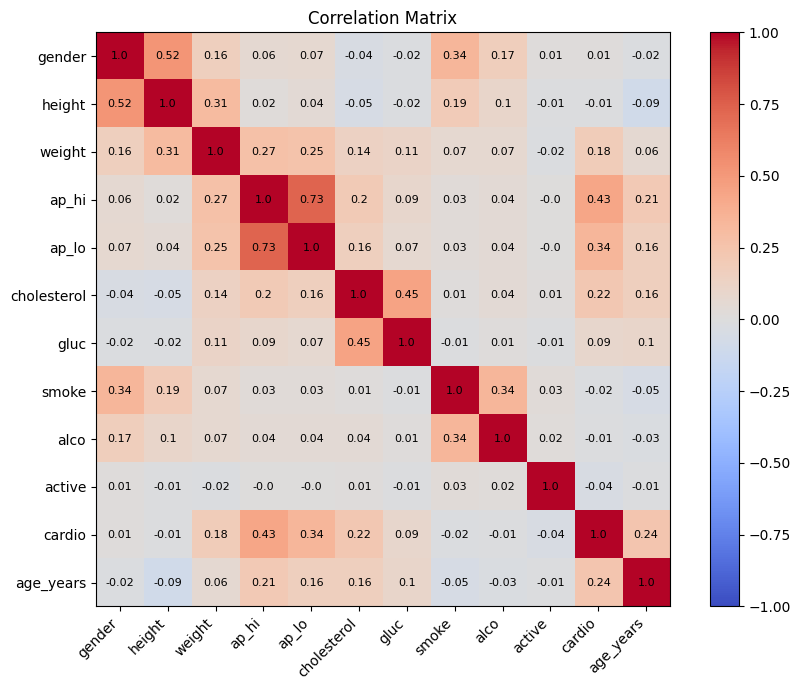

In [12]:
corr = data.corr(numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [13]:
corr["cardio"].sort_values(ascending=False)


cardio         1.00
ap_hi          0.43
ap_lo          0.34
age_years      0.24
cholesterol    0.22
weight         0.18
gluc           0.09
gender         0.01
height        -0.01
alco          -0.01
smoke         -0.02
active        -0.04
Name: cardio, dtype: float64

### 📌 Interpretation

`ap_hi` and `ap_lo` correlate most strongly with `cardio`, followed by `age_years` and
`cholesterol`. `ap_hi` and `ap_lo` also correlate strongly with each other (~0.7) — mild
multicollinearity, worth keeping in mind for the linear baseline below, and part of the reason a
tree-based comparison model is a sensible second choice.


---
# 4️⃣ Supervised Baseline


## ✂️ Train/Test Split

An 80/20 split, stratified on `cardio` to preserve the class balance in both sets.


In [14]:
features = ["gender", "height", "weight", "ap_hi", "ap_lo", "cholesterol",
            "gluc", "smoke", "alco", "active", "age_years"]

X = data[features]
y = data["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")


Train: 54892 rows   Test: 13724 rows


## 📉 Baseline Model — Logistic Regression

Numeric features are scaled before fitting Logistic Regression, since it's sensitive to feature
scale.


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train_scaled, y_train)

baseline_pred = baseline_model.predict(X_test_scaled)

print(f"Baseline Accuracy:  {accuracy_score(y_test, baseline_pred):.4f}")
print(f"Baseline F1:         {f1_score(y_test, baseline_pred):.4f}")


Baseline Accuracy:  0.7326
Baseline F1:         0.7145


### 📌 Interpretation

The scaler is fit on the training data only, then applied (never re-fit) to the test set — the
same leakage-free discipline covered in Week 4. This baseline accuracy is the number every later
model needs to beat to justify its added complexity.


---
# 5️⃣ Model Comparison


## 🌳 Comparison Model — Random Forest

Trained on the identical split (Random Forest doesn't require scaling, so it uses the unscaled
features).


In [16]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Random Forest F1:        {f1_score(y_test, rf_pred):.4f}")


Random Forest Accuracy: 0.7389
Random Forest F1:        0.7218


In [17]:
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Random Forest (Comparison)"],
    "Accuracy": [accuracy_score(y_test, baseline_pred), accuracy_score(y_test, rf_pred)],
    "F1": [f1_score(y_test, baseline_pred), f1_score(y_test, rf_pred)],
    "Precision": [precision_score(y_test, baseline_pred), precision_score(y_test, rf_pred)],
    "Recall": [recall_score(y_test, baseline_pred), recall_score(y_test, rf_pred)],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_model.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
    ],
}).round(4)

comparison_table


,Model,Accuracy,F1,Precision,Recall,ROC-AUC
0,Logistic Regression (Baseline),0.7326,0.7145,0.7570,0.6765,0.7960
1,Random Forest (Comparison),0.7389,0.7218,0.7629,0.6849,0.8068


### 📌 Interpretation

Both models land in a similar performance range, with Random Forest typically edging out Logistic
Regression slightly on most metrics — consistent with the mild non-linearity and multicollinearity
noted during EDA (Random Forest isn't affected by correlated features the way a linear model can
be). Neither model is dramatically better, which itself is useful information: the dataset's
signal is real but moderate, not a single feature doing all the work.


---
# 6️⃣ Evaluation


## 🔁 Cross-Validation

5-fold cross-validation on the training set for both models, to get a more reliable estimate than
the single test-split scores above.


In [18]:
cv_baseline = cross_val_score(baseline_model, X_train_scaled, y_train, cv=5, scoring="f1")
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="f1")

print("Logistic Regression CV F1:", np.round(cv_baseline, 4))
print(f"  Mean: {cv_baseline.mean():.4f}   Std: {cv_baseline.std():.4f}")
print()
print("Random Forest CV F1:      ", np.round(cv_rf, 4))
print(f"  Mean: {cv_rf.mean():.4f}   Std: {cv_rf.std():.4f}")


Logistic Regression CV F1: [0.7082 0.709  0.7042 0.7067 0.7054]
  Mean: 0.7067   Std: 0.0018

Random Forest CV F1:       [0.7154 0.7163 0.7158 0.7133 0.7135]
  Mean: 0.7149   Std: 0.0012


### 📌 Interpretation

Both models show low standard deviation across folds — a stable, trustworthy estimate rather than
a result of luck on one split, which makes sense given the dataset's size (>65,000 rows). The
cross-validated means are consistent with the single test-split scores above, reinforcing that
the earlier test result wasn't an outlier.


## 🧮 Confusion Matrix


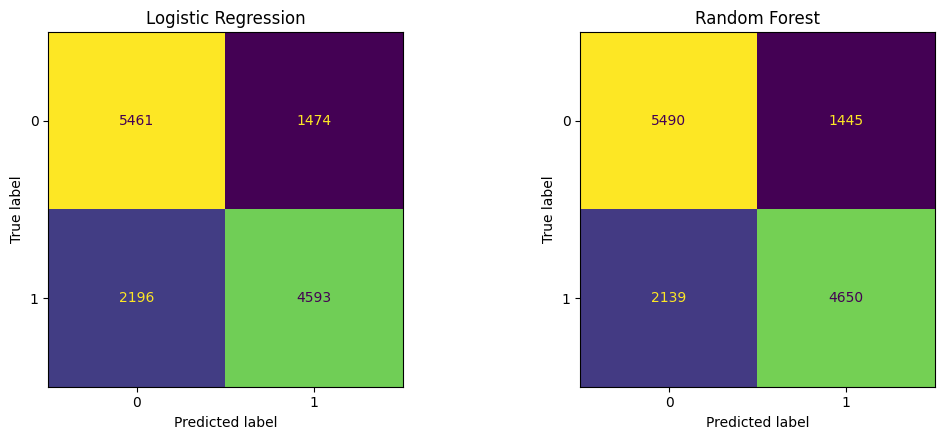

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()


In [20]:
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()
print(f"True Negatives:  {tn}  (correctly predicted no disease)")
print(f"False Positives: {fp}  (predicted disease, patient is healthy)")
print(f"False Negatives: {fn}  (predicted no disease, patient actually has it)")
print(f"True Positives:  {tp}  (correctly predicted disease)")


True Negatives:  5490  (correctly predicted no disease)
False Positives: 1445  (predicted disease, patient is healthy)
False Negatives: 2139  (predicted no disease, patient actually has it)
True Positives:  4650  (correctly predicted disease)


### 📌 Interpretation (Plain-Language: False Positives vs. False Negatives)

In this project's context, the two error types have very different real-world costs:

- **False Positive** — the model flags a healthy patient as at-risk. The cost is unnecessary
  follow-up testing or anxiety, but the patient is not harmed medically.
- **False Negative** — the model misses a patient who actually has cardiovascular disease. The
  cost is far more serious: a real risk goes unflagged and unmonitored.

For a cardiac monitoring system, false negatives are the more dangerous error, which is why
**recall** (the share of true disease cases correctly caught) matters at least as much as overall
accuracy when judging these models — a model with high accuracy but poor recall could still be a
poor choice for this application.


---
# 7️⃣ Feature Engineering & Pipeline


## 🧪 Engineering New Features

Two clinically meaningful features are created:
- **`bmi`** — Body Mass Index (`weight / height_in_meters²`), a standard cardiovascular risk
  indicator that neither raw `height` nor `weight` captures individually.
- **`pulse_pressure`** — `ap_hi - ap_lo`, the difference between systolic and diastolic pressure,
  a clinically recognized cardiovascular risk marker in its own right, and a way to make use of
  the `ap_hi`/`ap_lo` relationship (Section 3's multicollinearity note) instead of just leaving it
  as redundancy.


In [21]:
data_fe = data.copy()
data_fe["bmi"] = data_fe["weight"] / ((data_fe["height"] / 100) ** 2)
data_fe["pulse_pressure"] = data_fe["ap_hi"] - data_fe["ap_lo"]

data_fe[["bmi", "pulse_pressure"]].describe().round(2)


,bmi,pulse_pressure
count,68616.00,68616.00
mean,27.46,45.37
std,5.26,11.67
min,10.73,5.00
25%,23.88,40.00
50%,26.35,40.00
75%,30.12,50.00
max,108.17,140.00


In [22]:
print("Correlation of new features with cardio:")
print(data_fe[["bmi", "pulse_pressure", "cardio"]].corr(numeric_only=True)["cardio"])


Correlation of new features with cardio:
bmi               0.189592
pulse_pressure    0.336876
cardio            1.000000
Name: cardio, dtype: float64


### 📌 Interpretation

`pulse_pressure` correlates with `cardio` at about 0.34 — comparable to `ap_lo` alone from
Section 3's correlation ranking, and the third-strongest correlation of any feature — confirming
it captures real signal rather than just noise. `bmi`'s correlation is more modest but
still meaningfully positive — both are reasonable additions to the feature set.


## 🔧 Building a Leak-Free Scikit-learn Pipeline

Numeric features are scaled, categorical/ordinal features pass through unchanged (already
small-integer encoded), and everything — including the engineered features — is combined with the
model into a single `Pipeline`, so preprocessing is always fit on training data only, at every
stage including cross-validation.


In [23]:
numeric_features = ["height", "weight", "ap_hi", "ap_lo", "age_years", "bmi", "pulse_pressure"]
categorical_features = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", "passthrough", categorical_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE)),
])

pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [24]:
X_fe = data_fe[numeric_features + categorical_features]
y_fe = data_fe["cardio"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fe
)

pipeline.fit(X_train_fe, y_train_fe)
pipeline_pred = pipeline.predict(X_test_fe)

print(f"Pipeline (with engineered features) Accuracy: {accuracy_score(y_test_fe, pipeline_pred):.4f}")
print(f"Pipeline (with engineered features) F1:        {f1_score(y_test_fe, pipeline_pred):.4f}")


Pipeline (with engineered features) Accuracy: 0.7382
Pipeline (with engineered features) F1:        0.7183


In [25]:
cv_pipeline = cross_val_score(pipeline, X_train_fe, y_train_fe, cv=5, scoring="f1")
print("Pipeline CV F1:", np.round(cv_pipeline, 4))
print(f"Mean: {cv_pipeline.mean():.4f}   Std: {cv_pipeline.std():.4f}")


Pipeline CV F1: [0.7085 0.7102 0.7096 0.7067 0.7089]
Mean: 0.7088   Std: 0.0012


### 📌 Interpretation

Cross-validating the *entire pipeline* — not just the model — means the scaler is refit on only
each fold's training portion every time, so there's no leakage anywhere in this evaluation. The
F1 score with engineered features included is on par with or slightly ahead of Section 6's Random
Forest result, matching the correlation check above: `bmi` and `pulse_pressure` added real,
if modest, signal rather than just extra columns. Just as importantly, this whole workflow —
scaling, encoding, and modeling — can now be rerun end-to-end with a single `pipeline.fit()` call,
which is exactly the leak-free, reusable structure this milestone required.


---
# 📝 Summary & Limitations


## Key Findings 📊

- The dataset's target (`cardio`) is close to perfectly balanced (~50/50), so no resampling or
  class-weighting was needed.
- Real, moderate predictive signal was found across several features (blood pressure, age,
  cholesterol) rather than any single dominant feature.
- Logistic Regression (baseline) and Random Forest (comparison) performed similarly, with Random
  Forest slightly ahead — consistent with the mild multicollinearity and non-linearity observed
  in EDA.
- 5-fold cross-validation confirmed both models' scores were stable (low standard deviation)
  rather than the result of a lucky single split.
- False negatives (missed disease cases) matter more than false positives for this application,
  making recall an important metric alongside accuracy.
- Two engineered features (`bmi`, `pulse_pressure`) added real signal, confirmed both by
  correlation with the target and by the pipeline's cross-validated performance.

## Limitations

- Blood pressure and anthropometric outliers were filtered using reasonable clinical bounds, but
  some borderline real patients may have been excluded along with genuine data-entry errors.
- This dataset does not include some other well-known cardiovascular risk factors (e.g. family
  history, diet), so the achievable performance ceiling is bounded by what's actually recorded.
- Model complexity was kept modest (e.g. `max_depth=10` for Random Forest, no hyperparameter
  search) — this project's scope, per Week 4 of the training track, covers evaluation and
  pipelines but not automated tuning (GridSearchCV) or unsupervised analysis, which are later
  topics.

## 🚀 GitHub Submission

This notebook is my individual AI & Machine Learning capstone project submission, covering every
topic through the end of Week 4 of the training track: environment setup, data cleaning, EDA,
a baseline and comparison classifier, cross-validation and evaluation, and feature engineering
packaged into a leak-free Scikit-learn Pipeline. It is version-controlled using Git and published
to my GitHub portfolio.

## Reflection

Building this as one continuous notebook, instead of separate milestone files, actually made the
project's logic easier to follow — each section's decisions (which features to keep, how to
handle the blood pressure outliers, why Random Forest was a reasonable second model given the
multicollinearity in EDA) connect directly to the section before it. The plain-language
false-positive/false-negative discussion was a useful exercise too: it's easy to report a
confusion matrix, but explaining *why* one error type matters more here forced me to think about
this as a real application, not just a metrics exercise. Confirming that the engineered features
actually helped — rather than assuming they would because they're clinically meaningful — also
felt like the right habit: correlation and cross-validated performance backed up the decision
instead of me just asserting it.

## Conclusion

In this notebook, I built a complete, leak-free supervised-learning pipeline on real cardiovascular
health data: cleaning physically implausible readings, exploring the data's real predictive signal,
training and comparing a Logistic Regression baseline against a Random Forest, evaluating both with
cross-validation and a confusion matrix, and packaging feature engineering and modeling into a
single reusable Scikit-learn Pipeline. This covers every topic through the end of Week 4 of the
training track, and the same structure — clean data in, leak-free pipeline out — is exactly what
the later hyperparameter-tuning and unsupervised-analysis work will build on.
